In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, grayscale=False):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    return np.array(img).astype(np.float64) / 255

In [3]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

def build_gaussian_psf(H, W, sigma=3.0):
    y = np.fft.ifftshift(np.arange(-H // 2, H // 2))
    x = np.fft.ifftshift(np.arange(-W // 2, W // 2))
    X, Y = np.meshgrid(x, y)
    psf = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf

In [4]:
def compute_blurred_img(psf, orig_img, noise_amount=0.01):
    """Return the blurred image array by given psf."""
    
    eigen_val_A = np.fft.fft2(psf)
    blurred = np.real(np.fft.ifft2(eigen_val_A * np.fft.fft2(orig_img)))
    noise = noise_amount * np.random.randn(*orig_img.shape)
    
    return blurred + noise

def compute_blurred_img_rgb(psf, orig_img, noise_amount=0.01):
    """Return the blurred RGB image array by given psf."""
    
    eigen_val_A = np.fft.fft2(psf)
    blurred = np.zeros_like(orig_img, dtype=float)
    for c in range(orig_img.shape[2]):
        blurred[..., c] = np.real(np.fft.ifft2(eigen_val_A * np.fft.fft2(orig_img[..., c])))
    noise = noise_amount * np.random.randn(*orig_img.shape)
    
    return blurred + noise

In [5]:
def compute_naive(psf, blurred_img):
    eigen_val_A = np.fft.fft2(psf)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) / eigen_val_A))

def compute_naive_color(psf, blurred_img):
    eigen_A = np.fft.fft2(psf)
    result = np.zeros_like(blurred_img)
    with np.errstate(divide='ignore', invalid='ignore'):
        for c in range(3):
            result[:,:,c] = np.real(np.fft.ifft2(np.fft.fft2(blurred_img[:,:,c]) / eigen_A))
    return result

----------
### Visualization

In [6]:
def plot_comparison(arr_list, label_list, row, col, figsize=(12,4), cmap=None):
    """Plot images side by side for comparison."""
    
    _, sub = plt.subplots(row, col, figsize=figsize)
    sub = sub.flatten()
    [s.axis('off') for s in sub]
    
    for sub_idx in range(len(arr_list)):
        sub[sub_idx].imshow(arr_list[sub_idx], cmap=cmap)
        sub[sub_idx].set_title(label_list[sub_idx], y=-0.1)
        
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()

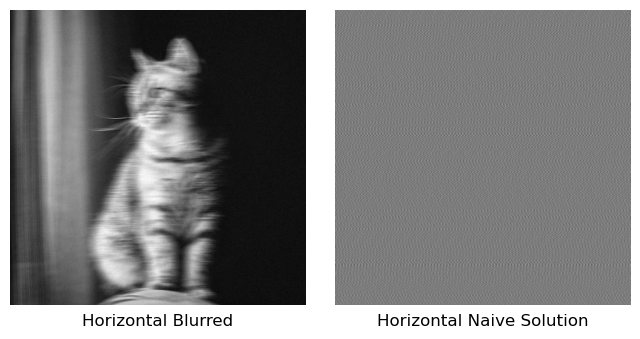

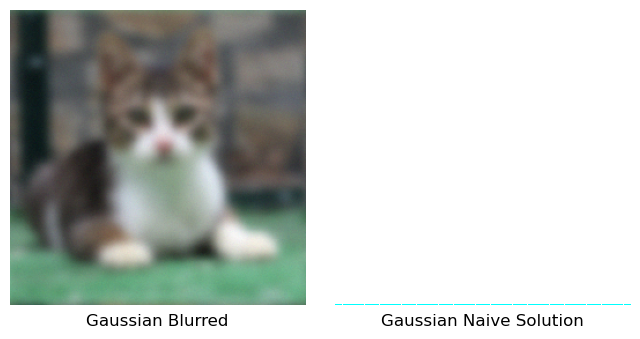

In [8]:
ex_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                                          grayscale=True)
ex_h_psf = build_horizontal_motion_psf(20, ex_gray_arr.shape)
ex_h_blurred = compute_blurred_img(ex_h_psf, ex_gray_arr)
ex_h_naive = compute_naive(ex_h_psf, ex_h_blurred)

ex_color_arr = convert_img_to_norm_np_arr('./color_deblur_img/kitten.jpg', grayscale=False)
ex_gauss_psf = build_gaussian_psf(ex_color_arr.shape[0], ex_color_arr.shape[1], sigma = 4.0)
ex_gauss_blurred = compute_blurred_img_rgb(ex_gauss_psf, ex_color_arr)
ex_gauss_naive = compute_naive_color(ex_gauss_psf, ex_gauss_blurred)




plot_comparison([ex_h_blurred, ex_h_naive],
          ['Horizontal Blurred', 'Horizontal Naive Solution'],
          1, 2, figsize=(8, 4), cmap='gray')

plot_comparison([ex_gauss_blurred, ex_gauss_naive],
          ['Gaussian Blurred', 'Gaussian Naive Solution'],
          1, 2, figsize=(8, 4))

